###데이터준비

In [ ]:
!pip cache purge

Files removed: 0


In [ ]:
!pip install transformers datasets torch scikit-learn

ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [ ]:


### 데이터 준비

import pandas as pd
from datasets import Dataset, DatasetDict

!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

train_df = pd.read_csv("ratings_train.txt", sep = "\t").dropna()
test_df = pd.read_csv("ratings_test.txt", sep = "\t").dropna()

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df)
})

print(dataset)

--2026-03-19 12:24:21--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt.3’

ratings_train.txt.3 100%[===================>]  13.95M  --.-KB/s    in 0.1s    

2026-03-19 12:24:21 (142 MB/s) - ‘ratings_train.txt.3’ saved [14628807/14628807]

--2026-03-19 12:24:21--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [application/oc

In [ ]:
print(train_df)

              id                                           document  label
0        9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1        3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2       10265843                                  너무재밓었다그래서보는것을추천한다      0
3        9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4        6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1
...          ...                                                ...    ...
149995   6222902                                인간이 문제지.. 소는 뭔죄인가..      0
149996   8549745                                      평점이 너무 낮아서...      1
149997   9311800                    이게 뭐요? 한국인은 거들먹거리고 필리핀 혼혈은 착하다?      0
149998   2376369                        청춘 영화의 최고봉.방황과 우울했던 날들의 자화상      1
149999   9619869                           한국 영화 최초로 수간하는 내용이 담긴 영화      0

[149995 rows x 3 columns]


### 데이터 전처리

In [ ]:
import re

def clean_text(text):
    # 한글과 공백만 남기고 특수문자, 숫자 등 제거
    text = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣ\s]', '', text)
    # 중복된 공백 제거
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_function(examples):
    # 'document' 컬럼에 clean_text 적용
    examples['document'] = [clean_text(doc) for doc in examples['document']]
    return examples

In [ ]:
# 1. 텍스트 정제 적용
dataset = dataset.map(preprocess_function, batched=True)

# 2. 빈 문자열 처리 (전처리 후 내용이 없어진 행 삭제)
dataset = dataset.filter(lambda x: len(x['document']) > 0)

# 3. 중복 데이터 제거 (Pandas를 활용해 간단히 처리 후 다시 Dataset으로)
train_df = dataset['train'].to_pandas().drop_duplicates(subset=['document'])
test_df = dataset['test'].to_pandas().drop_duplicates(subset=['document'])

from datasets import Dataset, DatasetDict
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False)
})

Map:   0%|          | 0/149995 [00:00<?, ? examples/s]

Map:   0%|          | 0/49997 [00:00<?, ? examples/s]

Filter:   0%|          | 0/149995 [00:00<?, ? examples/s]

Filter:   0%|          | 0/49997 [00:00<?, ? examples/s]

### Tokenizing

In [ ]:
from transformers import AutoTokenizer

# 한국어 → klue/bert-base, 영어 → bert-base-uncased
model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["document"], truncation=True, padding="max_length", max_length=64)

tokenized = dataset.map(tokenize, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Map:   0%|          | 0/143455 [00:00<?, ? examples/s]

Map:   0%|          | 0/48341 [00:00<?, ? examples/s]

### 모델 파인튜닝

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels = 2)

training_args = TrainingArguments(
    output_dir = "./results",
    num_train_epochs = 3,
    per_device_train_batch_size = 32,
    fp16=True,
    dataloader_num_workers=2,
    group_by_length=True,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True
)

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = tokenized["train"],
    eval_dataset = tokenized["test"]
)

trainer.train()

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Epoch,Training Loss,Validation Loss
1,0.272598,0.262247
2,0.180569,0.286640
3,0.097923,0.380981


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=13449, training_loss=0.19716586651115295, metrics={'train_runtime': 1972.6084, 'train_samples_per_second': 218.171, 'train_steps_per_second': 6.818, 'total_flos': 1.41542236675008e+16, 'train_loss': 0.19716586651115295, 'epoch': 3.0})

### 평가 & 시각화

              precision    recall  f1-score   support

          부정       0.90      0.89      0.89     24089
          긍정       0.89      0.90      0.89     24252

    accuracy                           0.89     48341
   macro avg       0.89      0.89      0.89     48341
weighted avg       0.89      0.89      0.89     48341



<function matplotlib.pyplot.show(close=None, block=None)>

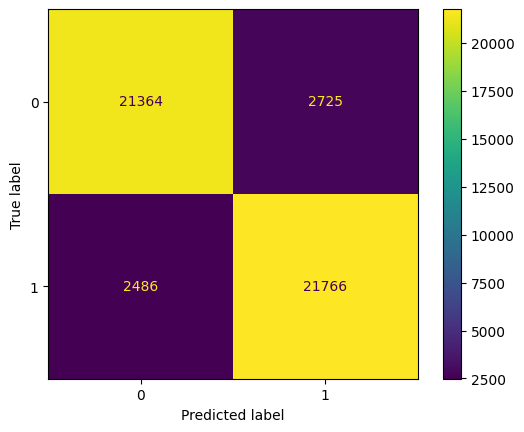

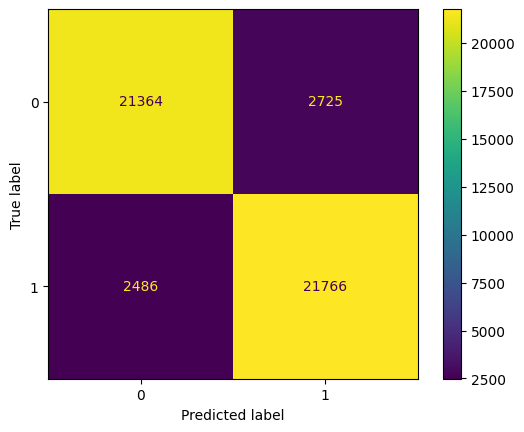

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = trainer.predict(tokenized["test"])
preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

print(classification_report(labels, preds, target_names = ["부정", "긍정"]))
ConfusionMatrixDisplay.from_predictions(labels, preds).plot()
plt.show